# Tarea 1 - Clasificacion de Pokemon Legendarios con MLP

Este cuadernillo resuelve la actividad usando redes neuronales MLP en PyTorch.
La idea central es construir un clasificador binario para predecir la columna `Legendary`.

**Nota para la entrega:** el enunciado pide que el archivo se llame `NG-MLP-Tarea1.ipynb`,
donde `NG` debe reemplazarse por el numero real de grupo.

## 1. Carga de librerias y configuracion

Se fija una semilla para que el experimento sea lo mas reproducible posible.

In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from models import MLPDeep, MLPMedium, MLPShallow

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo usado: {device}")

PyTorch: 2.10.0
Dispositivo usado: cuda


## 2. Explicacion del dataset

El dataset contiene 800 registros de Pokemon. Cada fila representa una criatura o una forma alternativa
y la variable objetivo es `Legendary`, que indica si el Pokemon es legendario.

Descripcion de columnas:

| Columna | Descripcion | Tipo esperado |
|---|---|---|
| `#` | Numero de la Pokedex. Puede repetirse en formas alternativas o megaevoluciones. | Entero |
| `Name` | Nombre del Pokemon o de la forma especifica. | Texto |
| `Type 1` | Tipo primario del Pokemon. | Categoria |
| `Type 2` | Tipo secundario. Puede faltar si el Pokemon tiene un solo tipo. | Categoria |
| `Total` | Suma de las seis estadisticas base. | Numerico |
| `HP` | Puntos de salud. | Numerico |
| `Attack` | Ataque fisico. | Numerico |
| `Defense` | Defensa fisica. | Numerico |
| `Sp. Atk` | Ataque especial. | Numerico |
| `Sp. Def` | Defensa especial. | Numerico |
| `Speed` | Velocidad. | Numerico |
| `Generation` | Generacion en la que aparece el Pokemon. | Categoria ordinal aparente |
| `Legendary` | Variable objetivo binaria. | Booleano |

In [2]:
data_path = Path("Pokemon.csv")
data = pd.read_csv(data_path)

display(data.head())
print(f"Filas: {data.shape[0]} | Columnas: {data.shape[1]}")

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Filas: 800 | Columnas: 13


In [3]:
column_descriptions = {
    "#": "Numero de Pokedex; puede repetirse para formas alternativas.",
    "Name": "Nombre del Pokemon o de su forma.",
    "Type 1": "Tipo primario.",
    "Type 2": "Tipo secundario; los nulos significan que no existe segundo tipo.",
    "Total": "Suma de HP, Attack, Defense, Sp. Atk, Sp. Def y Speed.",
    "HP": "Puntos de salud.",
    "Attack": "Ataque fisico.",
    "Defense": "Defensa fisica.",
    "Sp. Atk": "Ataque especial.",
    "Sp. Def": "Defensa especial.",
    "Speed": "Velocidad.",
    "Generation": "Generacion de aparicion; conviene tratarla como categorica.",
    "Legendary": "Objetivo: True si el Pokemon es legendario, False en caso contrario.",
}

summary = pd.DataFrame({
    "columna": data.columns,
    "tipo": [str(data[col].dtype) for col in data.columns],
    "nulos": [int(data[col].isna().sum()) for col in data.columns],
    "valores_unicos": [int(data[col].nunique(dropna=True)) for col in data.columns],
    "descripcion": [column_descriptions[col] for col in data.columns],
})
display(summary)

,columna,tipo,nulos,valores_unicos,descripcion
0,#,int64,0,721,Numero de Pokedex; puede repetirse para formas...
1,Name,str,0,800,Nombre del Pokemon o de su forma.
2,Type 1,str,0,18,Tipo primario.
3,Type 2,str,386,18,Tipo secundario; los nulos significan que no e...
4,Total,int64,0,200,"Suma de HP, Attack, Defense, Sp. Atk, Sp. Def ..."
5,HP,int64,0,94,Puntos de salud.
6,Attack,int64,0,111,Ataque fisico.
7,Defense,int64,0,103,Defensa fisica.
8,Sp. Atk,int64,0,105,Ataque especial.
9,Sp. Def,int64,0,92,Defensa especial.


In [4]:
display(data.describe(include="all"))

class_balance = data["Legendary"].value_counts().rename_axis("Legendary").to_frame("cantidad")
class_balance["porcentaje"] = class_balance["cantidad"] / len(data)
display(class_balance)

generation_balance = pd.crosstab(
    data["Generation"],
    data["Legendary"],
    margins=True,
)
display(generation_balance)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
count,800.0000,800,800,414,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800
unique,NaN,800,18,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Bulbasaur,Water,Flying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,1,112,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735
mean,362.8138,NaN,NaN,NaN,435.1025,69.2588,79.0012,73.8425,72.8200,71.9025,68.2775,3.3237,NaN
std,208.3438,NaN,NaN,NaN,119.9630,25.5347,32.4574,31.1835,32.7223,27.8289,29.0605,1.6613,NaN
min,1.0000,NaN,NaN,NaN,180.0000,1.0000,5.0000,5.0000,10.0000,20.0000,5.0000,1.0000,NaN
25%,184.7500,NaN,NaN,NaN,330.0000,50.0000,55.0000,50.0000,49.7500,50.0000,45.0000,2.0000,NaN
50%,364.5000,NaN,NaN,NaN,450.0000,65.0000,75.0000,70.0000,65.0000,70.0000,65.0000,3.0000,NaN
75%,539.2500,NaN,NaN,NaN,515.0000,80.0000,100.0000,90.0000,95.0000,90.0000,90.0000,5.0000,NaN


,cantidad,porcentaje
Legendary,,
False,735,0.9187
True,65,0.0813


Legendary,False,True,All
Generation,,,
1,160,6,166
2,101,5,106
3,142,18,160
4,108,13,121
5,150,15,165
6,74,8,82
All,735,65,800


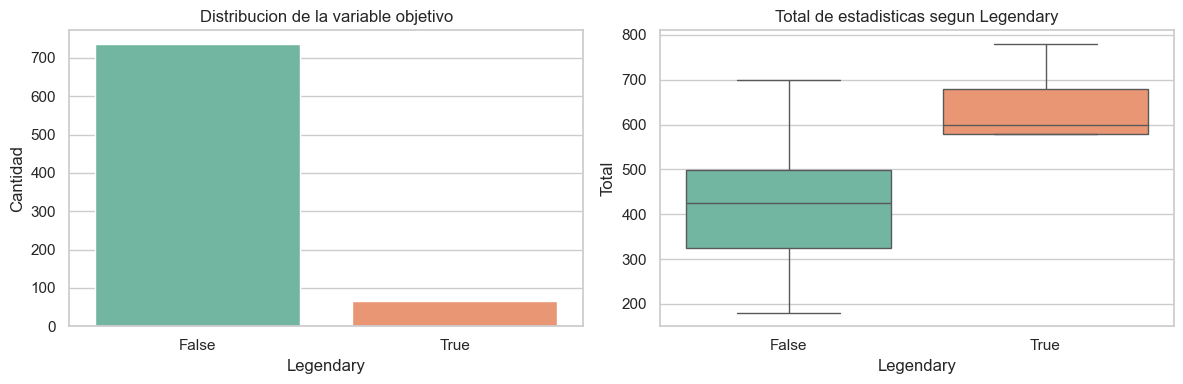

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=data, x="Legendary", hue="Legendary", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Distribucion de la variable objetivo")
axes[0].set_xlabel("Legendary")
axes[0].set_ylabel("Cantidad")

sns.boxplot(data=data, x="Legendary", y="Total", hue="Legendary", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Total de estadisticas segun Legendary")
axes[1].set_xlabel("Legendary")
axes[1].set_ylabel("Total")

plt.tight_layout()
plt.show()

### Comentario sobre la pista de la generacion

Interpreto la pista del profesor como una advertencia sobre la columna `Generation`.
Esta columna parece numerica, pero realmente identifica una categoria historica del juego.
Si se usa como numero continuo, el modelo podria asumir una relacion artificial como "generacion 6 es el doble
de generacion 3", lo cual no tiene sentido estadistico directo.

Ademas, la proporcion de legendarios cambia por generacion. Si se hace un `train_test_split` totalmente aleatorio,
alguna generacion podria quedar mal representada en validacion o test, especialmente porque solo hay 65 legendarios.
Por eso aqui se usa `Generation` para estratificar el split, pero no como predictor final.

Para el modelo final decidi no usar `Generation` como entrada. La razon es que la tarea busca distinguir
legendarios por sus atributos, y la generacion puede funcionar como una pista historica que no describe directamente
la capacidad del Pokemon. Usarla como predictor tambien puede aumentar el sobreajuste en un dataset pequeno.

La otra interpretacion posible es la seccion final de **IA Generativa** del enunciado: ahi simplemente se debe
declarar si se uso una herramienta como ChatGPT/Codex y en que partes.

## 3. Preparacion del dataset

Decisiones tomadas:

- `Name` y `#` no se usan como variables predictoras: identifican al Pokemon y pueden inducir memorizacion.
- `Type 2` se rellena con `No second type` para el analisis, porque un valor nulo aqui significa informacion real.
- Las variables numericas se estandarizan con `StandardScaler`.
- El modelo final usa las estadisticas numericas (`Total`, `HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`).
- `Type 1`, `Type 2` y `Generation` no se usan como predictores finales para reducir sobreajuste y evitar que la generacion se trate como una pista artificial.
- La clase positiva es minoritaria, asi que se usa `pos_weight` en la funcion de costo.
- Se crean conjuntos de entrenamiento, validacion y prueba. La validacion sirve para comparar arquitecturas y elegir umbral.

In [6]:
df = data.copy()
df["Type 2"] = df["Type 2"].fillna("No second type")
df["Legendary"] = df["Legendary"].astype(int)
df["Generation"] = df["Generation"].astype(str)

target_col = "Legendary"
numeric_features = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
categorical_features = []
dropped_features = ["#", "Name", "Type 1", "Type 2", "Generation"]

feature_cols = numeric_features + categorical_features
X_raw = df[feature_cols]
y = df[target_col].to_numpy()

stratify_key = df[target_col].astype(str) + "_G" + df["Generation"].astype(str)

X_train_raw, X_test_raw, y_train, y_test, key_train, key_test = train_test_split(
    X_raw,
    y,
    stratify_key,
    test_size=0.15,
    random_state=SEED,
    stratify=stratify_key,
)

X_train_raw, X_val_raw, y_train, y_val, key_train, key_val = train_test_split(
    X_train_raw,
    y_train,
    key_train,
    test_size=0.1765,
    random_state=SEED,
    stratify=key_train,
)

print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")
print("Proporcion de legendarios:")
print(pd.Series({
    "train": y_train.mean(),
    "val": y_val.mean(),
    "test": y_test.mean(),
}))

Train: 559 | Val: 121 | Test: 120
Proporcion de legendarios:
train   0.0805
val     0.0826
test    0.0833
dtype: float64


In [7]:
transformers = [("num", StandardScaler(), numeric_features)]
if categorical_features:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features))

preprocessor = ColumnTransformer(transformers=transformers, verbose_feature_names_out=False)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_val = preprocessor.transform(X_val_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

feature_names = preprocessor.get_feature_names_out()
input_dim = X_train.shape[1]

print(f"Numero de variables despues del preprocesamiento: {input_dim}")
display(pd.DataFrame({"feature": feature_names}).head(20))

Numero de variables despues del preprocesamiento: 7


,feature
0,Total
1,HP
2,Attack
3,Defense
4,Sp. Atk
5,Sp. Def
6,Speed


In [8]:
def make_loader(X, y, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


batch_size = 64
train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

positives = y_train.sum()
negatives = len(y_train) - positives
pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=device)
print(f"Peso para clase positiva en BCEWithLogitsLoss: {pos_weight.item():.2f}")

Peso para clase positiva en BCEWithLogitsLoss: 11.42


## 4. Definicion del modelo

Las tres arquitecturas estan definidas en `models.py`:

- `MLPShallow`: una capa oculta. Sirve como baseline de baja capacidad.
- `MLPMedium`: dos capas ocultas, batch normalization y dropout. Busca equilibrio entre capacidad y regularizacion.
- `MLPDeep`: tres capas ocultas. Prueba si una red mas profunda mejora o sobreajusta.

La salida de cada red es un unico logit. Esto permite usar `BCEWithLogitsLoss`, que combina sigmoid y binary cross entropy
de manera numericamente estable.

In [9]:
architectures = {
    "MLPShallow": lambda: MLPShallow(input_dim=input_dim, hidden_dim=24, dropout=0.10),
    "MLPMedium": lambda: MLPMedium(input_dim=input_dim, hidden_dim_1=64, hidden_dim_2=32, dropout=0.20),
    "MLPDeep": lambda: MLPDeep(input_dim=input_dim, hidden_dim_1=128, hidden_dim_2=64, hidden_dim_3=32, dropout=0.30),
}

for name, factory in architectures.items():
    model = factory()
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {n_params:,} parametros entrenables")

MLPShallow: 217 parametros entrenables
MLPMedium: 2,753 parametros entrenables
MLPDeep: 11,777 parametros entrenables


## 5. Optimizador y funcion de costo

Se usa:

- `BCEWithLogitsLoss`, adecuada para clasificacion binaria.
- `pos_weight`, porque hay muchos mas Pokemon no legendarios que legendarios.
- `AdamW`, que suele funcionar bien en MLP y agrega regularizacion mediante `weight_decay`.
- Early stopping con la perdida de validacion para evitar entrenar de mas.

In [10]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
max_epochs = 300
patience = 35
learning_rate = 1e-3
weight_decay = 1e-4

## 6. Entrenamiento y seleccion de arquitectura

Se entrenan las tres arquitecturas con los mismos hiperparametros.
Para seleccionar la mejor se usa F1 en validacion, porque el dataset esta desbalanceado y la exactitud puede verse alta
incluso si el modelo falla en la clase legendaria.

Si dos modelos empatan en F1 de validacion, se prefiere el modelo mas simple. Con pocos datos, menos parametros suele
generalizar mejor y es mas facil de justificar.

In [11]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(xb)
        n_samples += len(xb)

    return total_loss / n_samples


@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs = []
    for xb, _ in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs.append(torch.sigmoid(logits).detach().cpu().numpy())
    return np.concatenate(probs)


def best_threshold_for_f1(y_true, probs):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_true, probs >= t, zero_division=0) for t in thresholds]
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


def compute_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def train_model(name, factory):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = factory().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(model, train_loader, optimizer)
        val_loss = run_epoch(model, val_loader, optimizer=None)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    val_probs = predict_proba(model, val_loader)
    threshold, _ = best_threshold_for_f1(y_val, val_probs)
    val_metrics = compute_metrics(y_val, val_probs, threshold)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    val_metrics.update({
        "model": name,
        "epochs": len(history),
        "best_val_loss": best_val_loss,
        "n_params": n_params,
    })
    return model, pd.DataFrame(history), val_metrics


trained_models = {}
histories = {}
val_results = []

for name, factory in architectures.items():
    print(f"Entrenando {name}...")
    model, history, metrics = train_model(name, factory)
    trained_models[name] = model
    histories[name] = history
    val_results.append(metrics)

val_results_df = pd.DataFrame(val_results).sort_values(
    ["f1", "n_params", "pr_auc"],
    ascending=[False, True, False],
)
display(val_results_df)

selected_model_name = val_results_df.iloc[0]["model"]
selected_threshold = float(val_results_df.iloc[0]["threshold"])
selected_model = trained_models[selected_model_name]
print(f"Modelo seleccionado: {selected_model_name}")
print(f"Umbral seleccionado en validacion: {selected_threshold:.3f}")

Entrenando MLPShallow...


Entrenando MLPMedium...


Entrenando MLPDeep...


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,model,epochs,best_val_loss,n_params
0,0.8250,0.9752,0.7692,1.0000,0.8696,0.9824,0.7905,108,3,0,10,MLPShallow,300,0.2144,217
1,0.8350,0.9752,0.7692,1.0000,0.8696,0.9833,0.7994,108,3,0,10,MLPMedium,138,0.1923,2753
2,0.7150,0.9669,0.7143,1.0000,0.8333,0.9806,0.7755,107,4,0,10,MLPDeep,117,0.1951,11777


Modelo seleccionado: MLPShallow
Umbral seleccionado en validacion: 0.825


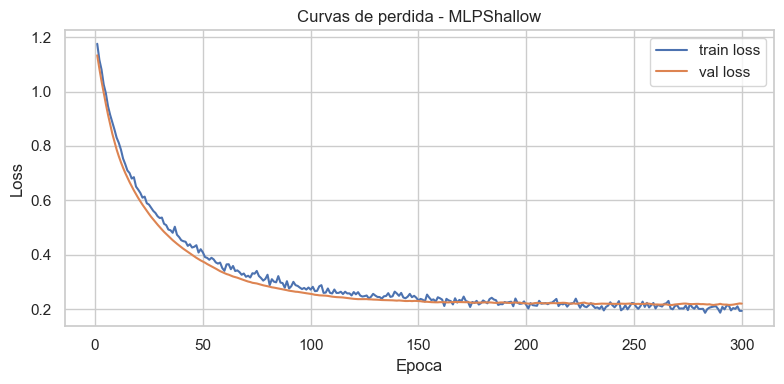

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
selected_history = histories[selected_model_name]
ax.plot(selected_history["epoch"], selected_history["train_loss"], label="train loss")
ax.plot(selected_history["epoch"], selected_history["val_loss"], label="val loss")
ax.set_title(f"Curvas de perdida - {selected_model_name}")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evaluacion del modelo

La evaluacion final se hace sobre el conjunto de prueba, que no fue usado para elegir arquitectura ni umbral.
Las metricas reportadas son:

- `accuracy`: proporcion total de aciertos.
- `precision`: de los predichos como legendarios, cuantos eran legendarios reales.
- `recall`: de los legendarios reales, cuantos fueron encontrados.
- `f1`: balance entre precision y recall.
- `roc_auc`: capacidad general de ranking entre clases.
- `pr_auc`: area precision-recall, especialmente util con clases desbalanceadas.

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,0.8250,0.9500,0.6667,0.8000,0.7273,0.9673,0.7889,106,4,2,8


,Pred no legendario,Pred legendario
Real no legendario,106,4
Real legendario,2,8


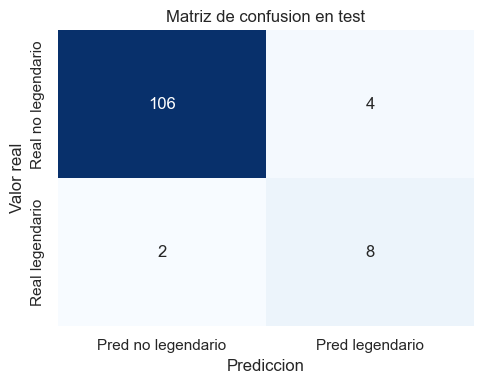

In [13]:
test_probs = predict_proba(selected_model, test_loader)
test_metrics = compute_metrics(y_test, test_probs, selected_threshold)
test_metrics_df = pd.DataFrame([test_metrics])
display(test_metrics_df)

test_preds = (test_probs >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, test_preds, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Real no legendario", "Real legendario"], columns=["Pred no legendario", "Pred legendario"])
display(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Matriz de confusion en test")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

In [14]:
test_report = data.loc[
    X_test_raw.index,
    ["#", "Name", "Type 1", "Type 2", "Generation", "Total"],
].copy()
test_report["Type 2"] = test_report["Type 2"].fillna("No second type")
test_report["Legendary_real"] = y_test
test_report["prob_legendary"] = test_probs
test_report["prediccion"] = test_preds
test_report["correcto"] = test_report["Legendary_real"] == test_report["prediccion"]
test_report = test_report.sort_values("prob_legendary", ascending=False)

display(test_report[["#", "Name", "Type 1", "Type 2", "Generation", "Total", "Legendary_real", "prob_legendary", "prediccion", "correcto"]].head(15))

misclassified = test_report[~test_report["correcto"]].copy()
if len(misclassified) > 0:
    print(f"Casos mal clasificados en test: {len(misclassified)}")
    display(misclassified[["#", "Name", "Type 1", "Type 2", "Generation", "Total", "Legendary_real", "prob_legendary", "prediccion"]])
else:
    print("No hubo casos mal clasificados en test. Se muestra el caso correcto mas cercano al umbral.")
    closest = test_report.iloc[(test_report["prob_legendary"] - selected_threshold).abs().argsort()[:1]]
    display(closest[["#", "Name", "Type 1", "Type 2", "Generation", "Total", "Legendary_real", "prob_legendary", "prediccion"]])

,#,Name,Type 1,Type 2,Generation,Total,Legendary_real,prob_legendary,prediccion,correcto
422,382,KyogrePrimal Kyogre,Water,No second type,3,770,1,0.9999,1,True
552,493,Arceus,Normal,No second type,4,720,1,0.9996,1,True
712,646,KyuremWhite Kyurem,Dragon,Ice,5,700,1,0.9971,1,True
541,484,Palkia,Water,Dragon,4,680,1,0.9964,1,True
710,646,Kyurem,Dragon,Ice,5,660,1,0.9905,1,True
546,488,Cresselia,Psychic,No second type,4,600,0,0.9779,1,False
165,151,Mew,Psychic,No second type,1,600,0,0.9729,1,False
268,248,TyranitarMega Tyranitar,Rock,Dark,2,700,0,0.9612,1,False
794,718,Zygarde50% Forme,Dragon,Ground,6,600,1,0.9569,1,True
154,142,AerodactylMega Aerodactyl,Rock,Flying,1,615,0,0.9450,1,False


Casos mal clasificados en test: 6


,#,Name,Type 1,Type 2,Generation,Total,Legendary_real,prob_legendary,prediccion
546,488,Cresselia,Psychic,No second type,4,600,0,0.9779,1
165,151,Mew,Psychic,No second type,1,600,0,0.9729,1
268,248,TyranitarMega Tyranitar,Rock,Dark,2,700,0,0.9612,1
154,142,AerodactylMega Aerodactyl,Rock,Flying,1,615,0,0.9450,1
415,378,Regice,Ice,No second type,3,580,1,0.3501,0
414,377,Regirock,Rock,No second type,3,580,1,0.0345,0


## 8. Preguntas finales

**1. Interpretacion de la matriz de confusion**

En la matriz de confusion:

- TN: Pokemon no legendarios correctamente clasificados como no legendarios.
- TP: Pokemon legendarios correctamente clasificados como legendarios.
- FP: Pokemon no legendarios que el modelo marco como legendarios. Es un falso aviso.
- FN: Pokemon legendarios que el modelo no detecto. Es un legendario perdido por el clasificador.

Si el objetivo fuera formar un equipo con legendarios reales, preferiria revisar los FN, porque aunque el modelo no los detecto,
su etiqueta real dice que si son legendarios. Si hubiera una restriccion de no usar legendarios, los FP tambien serian interesantes:
son Pokemon no legendarios con rasgos que el modelo encontro parecidos a los legendarios.

**2. Caso mal clasificado**

En la celda anterior se listan los casos mal clasificados. Por ejemplo, `Mew`, `Cresselia`,
`TyranitarMega Tyranitar` y `AerodactylMega Aerodactyl` aparecen como FP segun la etiqueta del dataset.
La razon probable es que tienen estadisticas totales altas o perfiles muy parecidos a los Pokemon legendarios,
por lo que el modelo los marca como legendarios aunque la etiqueta real sea 0.

Tambien aparecen FN como `Regice` y `Regirock`. Ambos son legendarios reales en el dataset, pero su `Total`
es 580, valor que no queda tan separado de varios Pokemon no legendarios fuertes. Por eso el modelo puede
confundirlos con no legendarios.

**3. Mayor desafio**

El mayor desafio fue el desbalance de clases: la mayoria de Pokemon no son legendarios. Si se usara solo accuracy,
un modelo podria parecer bueno aunque ignore muchos legendarios. Para resolverlo use `pos_weight`, F1, PR-AUC,
matriz de confusion y un split estratificado por `Legendary` y `Generation`.

## 9. IA Generativa

**1. Use alguna herramienta de IA Generativa?**

Si. Para esta version se uso ChatGPT/Codex como apoyo.

**2. En que partes se uso?**

Se uso para estructurar el cuadernillo, proponer el flujo de preprocesamiento, escribir y depurar el codigo de PyTorch,
comparar arquitecturas MLP, interpretar resultados y redactar explicaciones. Las decisiones tecnicas principales
quedaron reflejadas y verificadas ejecutando el notebook completo.